In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


### Checkig for null values

In [3]:
print(df.shape[0])

df.isna().sum()

5572


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [4]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis=1, inplace=True)

In [5]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Observation** : sice Unnamed : 2, Unnamed : 3, and Unnamed : 4 contains hughe number of null values, we removed them.

## Renaming the columns

In [6]:
df.rename(columns={'v1':'TARGET', 'v2':'INPUT'}, inplace=True)

In [7]:
df.head()

,TARGET,INPUT
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Using LabelEncoder() on TARGET

In [8]:
le = LabelEncoder()

df['TARGET'] = le.fit_transform(df['TARGET'])
print("0 corresponds to:", le.classes_[0])
print("1 corresponds to:", le.classes_[1])
df.head()

0 corresponds to: ham
1 corresponds to: spam


,TARGET,INPUT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Checking for duplicates

In [9]:
print(df.duplicated().sum())

403


In [10]:
df.drop_duplicates(keep='first')

,TARGET,INPUT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


### EDA

First we need to check what percentage of datas are spam and not spams

In [11]:
print(df['TARGET'].value_counts())

total_0 = df[df['TARGET'] == 0].shape[0]
total_1 = df[df['TARGET'] == 1].shape[0]

total = total_0 + total_1

percentage_0 = (total_0/total) * 100
percentage_1 = (total_1/total) * 100


print(f"\nPERCENTAGE OF 0 : {np.round(percentage_0, 2)} %")
print(f"PERCENTAGE OF 1 : {np.round(percentage_1, 2)} %")

TARGET
0    4825
1     747
Name: count, dtype: int64

PERCENTAGE OF 0 : 86.59 %
PERCENTAGE OF 1 : 13.41 %


Making a pie chart to do the same

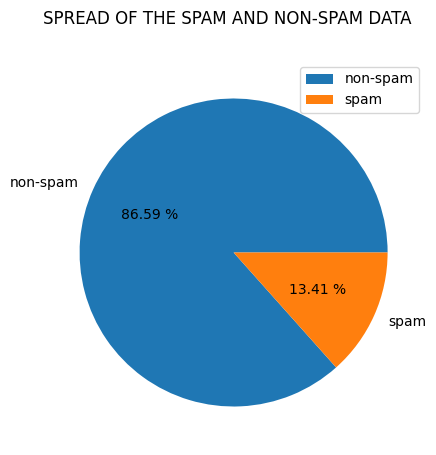

In [12]:
plt.figure(figsize=(5,5))
plt.pie(df['TARGET'].value_counts(), labels=['non-spam', 'spam'], autopct="%0.2f %%")
plt.suptitle('SPREAD OF THE SPAM AND NON-SPAM DATA')
plt.legend()
plt.show()

**Observation** : As we can see from the above data, that we have a case of **imbalanced dataset**, as we have 86% of non-spam data and only 13 % of spam data.

##### **Since we have only one input feature, hence now to move forward with the data we need to make 3 new features.**

Features required :
- NO_OF_CHARS : shows total numbers of characters in the sentence
- NO_OF_WORDS : shows total number of words in the sentence
- NO_OF_SENTNS : shows total numbner sentences

In [13]:
import nltk

nltk.download('punkt_tab')          # an important step during spam SMS detection

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\biswa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

If you are using `nltk` to split text into individual words or sentences (which is generally called tokenization, a very common step in Email Spam Detection), `nltk` requires a specific set of rules to know how to split the English language correctly. That rule set is called `punkt`.

Even though you `pip installed nltk`, it doesn't download all of its datasets by default because they are very large. You build it by hand.

In [14]:
# storing the characters
df['NO_OF_CHARS'] = df['INPUT'].apply(len)

# storing the words
df['ALL_WORDS'] = df['INPUT'].apply(lambda x : nltk.word_tokenize(x))
df['NO_OF_WORDS'] = df['INPUT'].apply(lambda x : len(nltk.word_tokenize(x)))

# storing the sentences
df['NO_OF_SENTNS'] = df['INPUT'].apply(lambda x : len(nltk.sent_tokenize(x)))

df.head()

,TARGET,INPUT,NO_OF_CHARS,ALL_WORDS,NO_OF_WORDS,NO_OF_SENTNS
0,0,"Go until jurong point, crazy.. Available only ...",111,"[Go, until, jurong, point, ,, crazy, .., Avail...",24,2
1,0,Ok lar... Joking wif u oni...,29,"[Ok, lar, ..., Joking, wif, u, oni, ...]",8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",37,2
3,0,U dun say so early hor... U c already then say...,49,"[U, dun, say, so, early, hor, ..., U, c, alrea...",13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,"[Nah, I, do, n't, think, he, goes, to, usf, ,,...",15,1


### Doing Stemming

In [15]:
from nltk.stem.porter import PorterStemmer
st = PorterStemmer()


# making a function to do the stemming
def stem(text):
    temp = []
    for i in text:
        temp.append(st.stem(i))
    return " ".join(temp)

In [16]:
stem('laughing')

'l a u g h i n g'

In [17]:
df['ALL_WORDS'] = df['ALL_WORDS'].apply(stem)
df.head()

,TARGET,INPUT,NO_OF_CHARS,ALL_WORDS,NO_OF_WORDS,NO_OF_SENTNS
0,0,"Go until jurong point, crazy.. Available only ...",111,"go until jurong point , crazi .. avail onli in...",24,2
1,0,Ok lar... Joking wif u oni...,29,ok lar ... joke wif u oni ...,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri in 2 a wkli comp to win fa cup fina...,37,2
3,0,U dun say so early hor... U c already then say...,49,u dun say so earli hor ... u c alreadi then sa...,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,"nah i do n't think he goe to usf , he live aro...",15,1


**Observation** : As it important to have ALL_WORDS so that the ML model can detect which words affect the model most for making it a spam or non-spam. And afterwards we will be dropping INPUT feature.

It is not strictly required for the final algorithm (because machine learning tools like `sklearn`'s `CountVectorizer` or `TfidfVectorizer` can take a full sentence and split it into words automatically behind the scenes).

However, it is HIGHLY **RECOMMENDED** to do it exactly the way we have done here.

In [18]:
df[['NO_OF_CHARS','NO_OF_WORDS','NO_OF_SENTNS']].describe()

,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [19]:
df[df['TARGET'] == 0][['NO_OF_CHARS','NO_OF_WORDS','NO_OF_SENTNS']].describe()

,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [20]:
df[df['TARGET'] == 1][['NO_OF_CHARS','NO_OF_WORDS','NO_OF_SENTNS']].describe()

,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


---
**Observation** : Here we can make an observation that mean for spam SMS are quite hire compared to non-spam SMS, this is bcoz usually spam messages are quite lengthier in context. But it can also contradicted by saying that if someone is writing a personal birthday SMS or some farewell SMS etc. the said SMS can also be lengthier. Which is proven from the `max` is quite higher in non-spam compared to spam.


## $$Word Clouds$$

---

### Plotting Histograms for better EDA

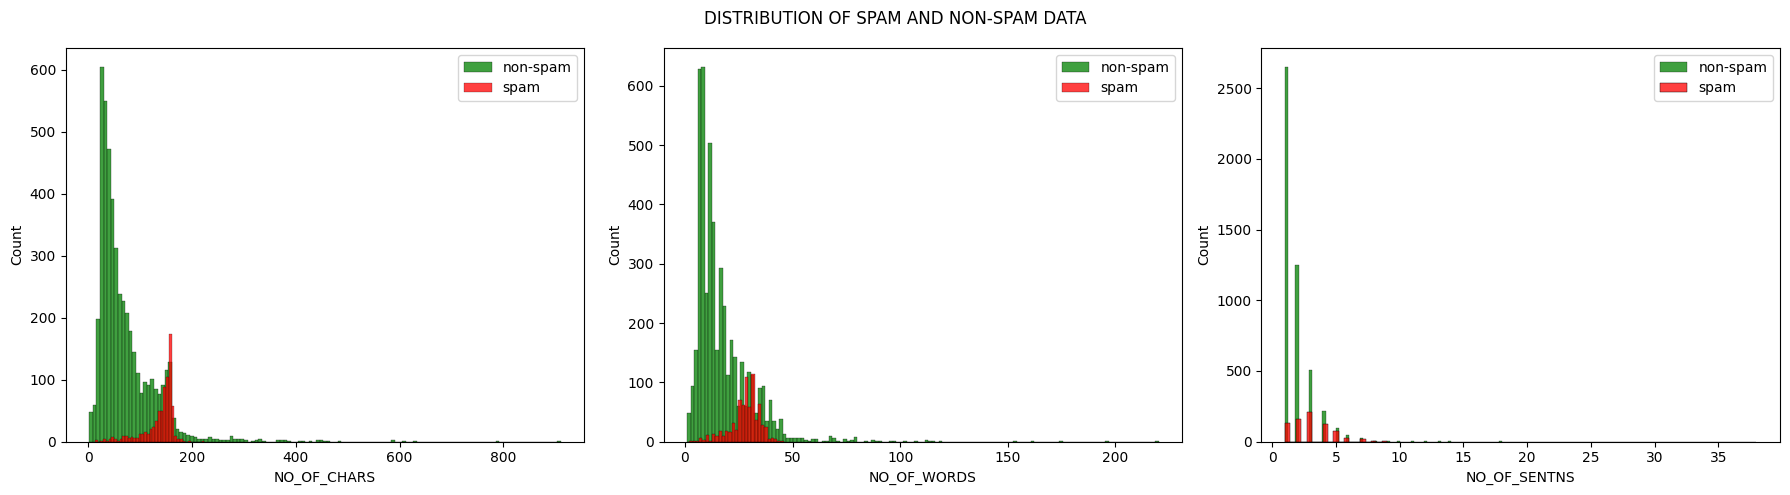

In [21]:
plt.figure(figsize=(18,5))
plt.subplot(131)
sns.histplot(df[df['TARGET'] == 0]['NO_OF_CHARS'], color='g', label='non-spam')
sns.histplot(df[df['TARGET'] == 1]['NO_OF_CHARS'], color='r', label='spam')
plt.legend()

plt.subplot(132)
sns.histplot(df[df['TARGET'] == 0]['NO_OF_WORDS'], color='g', label='non-spam')
sns.histplot(df[df['TARGET'] == 1]['NO_OF_WORDS'], color='r', label='spam')
plt.legend()

plt.subplot(133)
sns.histplot(df[df['TARGET'] == 0]['NO_OF_SENTNS'], color='g', label='non-spam')
sns.histplot(df[df['TARGET'] == 1]['NO_OF_SENTNS'], color='r', label='spam')

plt.legend()
plt.suptitle('DISTRIBUTION OF SPAM AND NON-SPAM DATA')
plt.tight_layout()
plt.show()